<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/L%C3%ADnea_de_espera_con_un_servidor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**LINEAS DE ESPERA**
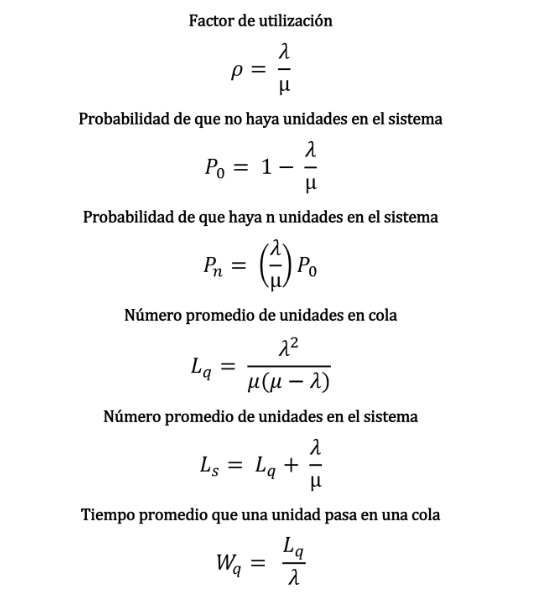

**Fórmulas de Línea de Espera**


Analiticamente se tiene:




In [2]:


import numpy as np
import random as r
import matplotlib.pyplot as plt


In [3]:

def generar_llegadas_poisson(lamda, T):
    """Genera tiempos de llegada para proceso Poisson homogéneo hasta T"""
    llegadas = []
    t = 0
    while t <= T:
        u = r.random()
        t = t - (1/lamda) * np.log(u)
        if t <= T:
            llegadas.append(t)
    return llegadas


In [4]:

def generar_llegadas_poisson(lamda, T):
    """Genera tiempos de llegada para proceso Poisson homogéneo hasta T"""
    llegadas = []
    t = 0
    while t <= T:
        u = r.random()
        t = t - (1/lamda) * np.log(u)
        if t <= T:
            llegadas.append(t)
    return llegadas


In [5]:

def generar_llegadas_poisson(lamda, T):
    """Genera tiempos de llegada para proceso Poisson homogéneo hasta T"""
    llegadas = []
    t = 0
    while t <= T:
        u = r.random()
        t = t - (1/lamda) * np.log(u)
        if t <= T:
            llegadas.append(t)
    return llegadas


SIMULACIÓN DE COLA CON UN SERVIDOR
Tasa de llegada (λ) = 2.0
Tasa de servicio (μ) = 1.5
Tiempo límite (T) = 10.0

[t=1.006] LLEGADA #1 - Clientes en sistema: 1
        Servidor empieza a atender - Duración: 0.131
[t=1.137] SALIDA #1 - Clientes en sistema: 0
        Sistema vacío - Servidor libre
[t=1.377] LLEGADA #2 - Clientes en sistema: 1
        Servidor empieza a atender - Duración: 1.611
[t=2.305] LLEGADA #3 - Clientes en sistema: 2
[t=2.988] SALIDA #2 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.414
[t=3.246] LLEGADA #4 - Clientes en sistema: 2
[t=3.402] SALIDA #3 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.244
[t=3.646] SALIDA #4 - Clientes en sistema: 0
        Sistema vacío - Servidor libre
[t=5.215] LLEGADA #5 - Clientes en sistema: 1
        Servidor empieza a atender - Duración: 0.122
[t=5.337] SALIDA #5 - Clientes en sistema: 0
        Sistema vacío - Servidor libre
[t=5.554] LLEGADA #6 - Clientes en sistema: 1
  

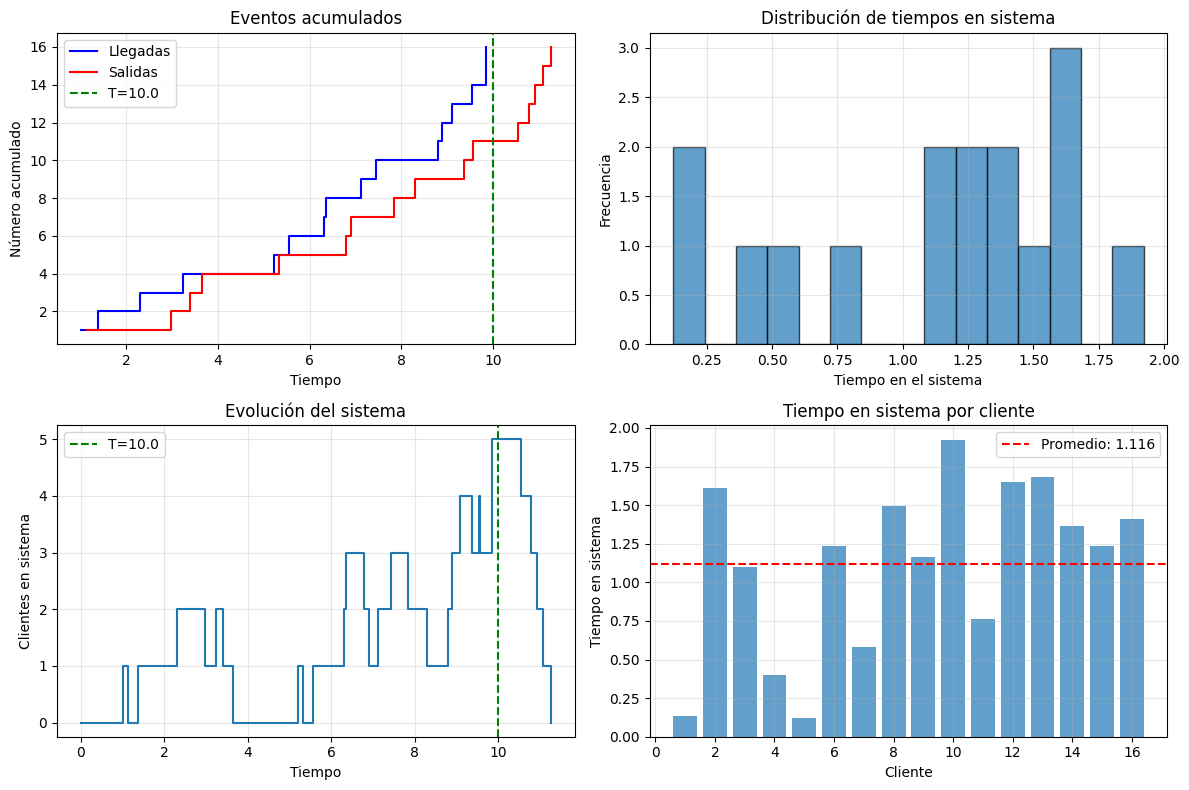


MÚLTIPLES SIMULACIONES (20 corridas)

SIMULACIÓN DE COLA CON UN SERVIDOR
Tasa de llegada (λ) = 2.0
Tasa de servicio (μ) = 1.5
Tiempo límite (T) = 10.0

[t=1.899] LLEGADA #1 - Clientes en sistema: 1
        Servidor empieza a atender - Duración: 0.626
[t=2.099] LLEGADA #2 - Clientes en sistema: 2
[t=2.371] LLEGADA #3 - Clientes en sistema: 3
[t=2.525] SALIDA #1 - Clientes en sistema: 2
        Siguiente cliente - Duración servicio: 0.171
[t=2.636] LLEGADA #4 - Clientes en sistema: 3
[t=2.697] SALIDA #2 - Clientes en sistema: 2
        Siguiente cliente - Duración servicio: 0.335
[t=3.008] LLEGADA #5 - Clientes en sistema: 3
[t=3.032] SALIDA #3 - Clientes en sistema: 2
        Siguiente cliente - Duración servicio: 0.137
[t=3.169] SALIDA #4 - Clientes en sistema: 1
        Siguiente cliente - Duración servicio: 0.100
[t=3.269] SALIDA #5 - Clientes en sistema: 0
        Sistema vacío - Servidor libre
[t=3.657] LLEGADA #6 - Clientes en sistema: 1
        Servidor empieza a atender - Durac

In [7]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

def generar_servicio_exponencial(mu):
    """Genera un tiempo de servicio exponencial con tasa mu"""
    return - (1/mu) * np.log(r.random())

def simular_cola(lamda, mu, T):
    """
    Simula sistema de cola con un servidor

    Parámetros:
    lamda: tasa de llegada (Poisson)
    mu: tasa de servicio (exponencial)
    T: tiempo límite para nuevas llegadas

    Retorna:
    A: lista de tiempos de llegada
    D: lista de tiempos de salida
    TP: tiempo de salida del último cliente
    """

    # ========== INICIALIZACIÓN ==========
    t = 0.0              # tiempo actual
    NA = 0               # número de llegadas
    ND = 0               # número de salidas
    n = 0                # clientes en el sistema

    # Lista de eventos
    llegadas = generar_llegadas_poisson(lamda, T)  # todas las llegadas hasta T
    llegadas.append(float('inf'))  # centinela para evitar errores

    tA = llegadas[0]     # próxima llegada
    tD = float('inf')    # próxima salida

    # Datos de salida
    A = []               # tiempos de llegada
    D = []               # tiempos de salida
    TP = None            # tiempo último cliente

    # Índice para recorrer llegadas
    idx_llegadas = 0

    print("\n" + "="*70)
    print("SIMULACIÓN DE COLA CON UN SERVIDOR")
    print("="*70)
    print(f"Tasa de llegada (λ) = {lamda}")
    print(f"Tasa de servicio (μ) = {mu}")
    print(f"Tiempo límite (T) = {T}")
    print("="*70 + "\n")

    # ========== BUCLE PRINCIPAL ==========
    while True:

        # CASO 1: LLEGADA (tA <= tD y tA <= T)
        if tA <= tD and tA <= T:
            t = tA
            NA += 1
            n += 1
            A.append(t)

            print(f"[t={t:.3f}] LLEGADA #{NA} - Clientes en sistema: {n}")

            # Siguiente llegada
            idx_llegadas += 1
            tA = llegadas[idx_llegadas]

            # Si el servidor estaba vacío (n=1 significa que recién llegó el primero)
            if n == 1:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
                print(f"        Servidor empieza a atender - Duración: {Y:.3f}")

        # CASO 2: SALIDA ANTES DE T (tD < tA y tD <= T)
        elif tD < tA and tD <= T:
            t = tD
            n -= 1
            ND += 1
            D.append(t)

            print(f"[t={t:.3f}] SALIDA #{ND} - Clientes en sistema: {n}")

            # Si hay más clientes en cola
            if n == 0:
                tD = float('inf')
                print(f"        Sistema vacío - Servidor libre")
            else:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
                print(f"        Siguiente cliente - Duración servicio: {Y:.3f}")

        # CASO 3: DESPUÉS DE T (min(tA, tD) > T y n > 0)
        elif min(tA, tD) > T and n > 0:
            t = tD
            n -= 1
            ND += 1
            D.append(t)

            print(f"[t={t:.3f}] SALIDA #{ND} (después de T={T}) - Clientes restantes: {n}")

            if n == 0:
                tD = float('inf')
                TP = t
                print(f"        *** ÚLTIMO CLIENTE - Tiempo final: {t:.3f} ***")
            else:
                Y = generar_servicio_exponencial(mu)
                tD = t + Y
                print(f"        Siguiente cliente - Duración: {Y:.3f}")

        else:
            # Fin de la simulación
            print("\n" + "="*70)
            print("FIN DE LA SIMULACIÓN")
            print("="*70)
            break

    # ========== RESULTADOS ==========
    print(f"\nRESUMEN:")
    print(f"  Total llegadas: {NA}")
    print(f"  Total salidas: {ND}")
    print(f"  Último cliente salió en: {TP:.3f}" if TP else "  No hubo clientes")

    # Calcular tiempo promedio en el sistema
    tiempos_sistema = []
    for i in range(min(len(A), len(D))):
        tiempo = D[i] - A[i]
        tiempos_sistema.append(tiempo)
        print(f"  Cliente {i+1}: llegó={A[i]:.3f}, salió={D[i]:.3f}, tiempo={tiempo:.3f}")

    if tiempos_sistema:
        tiempo_promedio = np.mean(tiempos_sistema)
        print(f"\n(a) Tiempo promedio en el sistema: {tiempo_promedio:.4f}")

    if TP:
        tiempo_cierre = max(0, TP - T)
        print(f"(b) Tiempo después de T hasta último cliente: {tiempo_cierre:.4f}")

    return A, D, TP, tiempos_sistema

def graficar_resultados(A, D, T):
    """Grafica los resultados de la simulación"""

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Gráfico 1: Llegadas acumuladas
    axes[0, 0].step(A, range(1, len(A) + 1), where='post', label='Llegadas', color='blue')
    axes[0, 0].step(D, range(1, len(D) + 1), where='post', label='Salidas', color='red')
    axes[0, 0].axvline(x=T, color='green', linestyle='--', label=f'T={T}')
    axes[0, 0].set_xlabel('Tiempo')
    axes[0, 0].set_ylabel('Número acumulado')
    axes[0, 0].set_title('Eventos acumulados')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Gráfico 2: Histograma de tiempos en sistema
    tiempos = [D[i] - A[i] for i in range(min(len(A), len(D)))]
    axes[0, 1].hist(tiempos, bins=15, edgecolor='black', alpha=0.7)
    axes[0, 1].set_xlabel('Tiempo en el sistema')
    axes[0, 1].set_ylabel('Frecuencia')
    axes[0, 1].set_title('Distribución de tiempos en sistema')
    axes[0, 1].grid(True, alpha=0.3)

    # Gráfico 3: Evolución de clientes
    eventos = []
    for t in A:
        eventos.append((t, 1))
    for t in D:
        eventos.append((t, -1))
    eventos.sort()

    tiempo_eventos = [0]
    clientes = [0]
    actual = 0
    for t, cambio in eventos:
        tiempo_eventos.append(t)
        clientes.append(actual)
        actual += cambio
        tiempo_eventos.append(t)
        clientes.append(actual)

    axes[1, 0].step(tiempo_eventos, clientes, where='post')
    axes[1, 0].axvline(x=T, color='green', linestyle='--', label=f'T={T}')
    axes[1, 0].set_xlabel('Tiempo')
    axes[1, 0].set_ylabel('Clientes en sistema')
    axes[1, 0].set_title('Evolución del sistema')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Gráfico 4: Tiempos individuales
    indices = range(1, min(len(A), len(D)) + 1)
    axes[1, 1].bar(indices, tiempos, alpha=0.7)
    axes[1, 1].axhline(y=np.mean(tiempos), color='red', linestyle='--', label=f'Promedio: {np.mean(tiempos):.3f}')
    axes[1, 1].set_xlabel('Cliente')
    axes[1, 1].set_ylabel('Tiempo en sistema')
    axes[1, 1].set_title('Tiempo en sistema por cliente')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def multiples_simulaciones(lamda, mu, T, n_sim=30):
    """Ejecuta múltiples simulaciones y calcula promedios"""

    print("\n" + "="*70)
    print(f"MÚLTIPLES SIMULACIONES ({n_sim} corridas)")
    print("="*70)

    tiempos_promedio = []
    tiempos_cierre = []

    for i in range(n_sim):
        A, D, TP, tiempos_sistema = simular_cola(lamda, mu, T)
        if tiempos_sistema:
            tiempos_promedio.append(np.mean(tiempos_sistema))
        if TP:
            tiempos_cierre.append(max(0, TP - T))

    if tiempos_promedio:
        print(f"\nRESULTADOS PROMEDIO:")
        print(f"  Tiempo promedio en sistema: {np.mean(tiempos_promedio):.4f} \u00b1 {np.std(tiempos_promedio):.4f}")
    if tiempos_cierre:
        print(f"  Tiempo promedio de cierre: {np.mean(tiempos_cierre):.4f} \u00b1 {np.std(tiempos_cierre):.4f}")

# ========== EJECUCIÓN ==========
if __name__ == "__main__":
    # Parámetros
    lamda = 2.0    # tasa de llegada (clientes por unidad de tiempo)
    mu = 1.5       # tasa de servicio (clientes por unidad de tiempo)
    T = 10.0       # tiempo límite para llegadas

    # Una simulación detallada
    A, D, TP, tiempos = simular_cola(lamda, mu, T)

    # Graficar resultados
    graficar_resultados(A, D, T)

    # Múltiples simulaciones
    multiples_simulaciones(lamda, mu, T, n_sim=20)